# 03 — Regression Models
### PMSM Winding Process — Quality Prediction Project
---
**Goal:** Train and compare regression models to predict slot fill factor, winding resistance, insulation integrity score and process stability index.  
**Models:** Linear Regression · Random Forest · XGBoost  
**Metrics:** R² · MAE · RMSE


## 1. Imports & Config

In [1]:
import os
os.chdir(os.path.dirname(os.path.abspath('03_Regression.ipynb')))
print("Working directory:", os.getcwd())


Working directory: d:\Downloads\PMSM Winding Project\pmsm-winding-quality-prediction\notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, KFold, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.size': 11, 'axes.titlesize': 12,
})

os.makedirs('../results/plots', exist_ok=True)
os.makedirs('../src', exist_ok=True)
SEED = 42
np.random.seed(SEED)
print("Imports OK.")


Imports OK.


## 2. Load Processed Data

In [3]:
train = pd.read_csv('../data/processed/train.csv')
val   = pd.read_csv('../data/processed/val.csv')
test  = pd.read_csv('../data/processed/test.csv')

TARGETS_REG = ['slot_fill_factor_pct', 'winding_resistance_mOhm',
               'insulation_integrity_score', 'process_stability_index']
TARGET_CLF  = 'insulation_failure'

with open('../src/feature_list.txt') as f:
    FEATURES = [line.strip() for line in f.readlines()]

X_train = train[FEATURES]
X_val   = val[FEATURES]
X_test  = test[FEATURES]

y_train = train[TARGETS_REG]
y_val   = val[TARGETS_REG]
y_test  = test[TARGETS_REG]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Features: {len(FEATURES)}")


Train : (350, 44)
Val   : (75, 44)
Test  : (75, 44)
Features: 44


## 3. Define Models

In [4]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0, random_state=SEED),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200, max_depth=12,
                             min_samples_leaf=3, random_state=SEED, n_jobs=-1),
    'XGBoost':           XGBRegressor(
                             n_estimators=300, max_depth=6, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             random_state=SEED, verbosity=0, n_jobs=-1),
}
print("Models defined:")
for name in models:
    print(f"  {name}")


Models defined:
  Linear Regression
  Ridge Regression
  Random Forest
  XGBoost


## 4. Train & Evaluate All Models on All Targets

In [5]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    r2   = r2_score(y_te, preds)
    mae  = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    return r2, mae, rmse, preds

results = {}   # results[target][model_name] = {r2, mae, rmse}
predictions = {}  # predictions[target][model_name] = array

for target in TARGETS_REG:
    results[target] = {}
    predictions[target] = {}
    print(f"\n{'='*55}")
    print(f"Target: {target}")
    print(f"{'='*55}")
    print(f"  {'Model':<22} {'R²':>7} {'MAE':>10} {'RMSE':>10}")
    print(f"  {'-'*52}")
    for name, model in models.items():
        r2, mae, rmse, preds = evaluate(
            model,
            X_train, y_train[target],
            X_val,   y_val[target]
        )
        results[target][name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse}
        predictions[target][name] = preds
        print(f"  {name:<22} {r2:>7.4f} {mae:>10.4f} {rmse:>10.4f}")



Target: slot_fill_factor_pct
  Model                       R²        MAE       RMSE
  ----------------------------------------------------
  Linear Regression       0.9686     3.3336     4.1664
  Ridge Regression        0.9427     4.1823     5.6283
  Random Forest           0.9842     1.9230     2.9523
  XGBoost                 0.9840     1.8819     2.9772

Target: winding_resistance_mOhm
  Model                       R²        MAE       RMSE
  ----------------------------------------------------
  Linear Regression       0.8375   452.0261   541.1691
  Ridge Regression        0.8349   456.6714   545.4071
  Random Forest           0.9957    48.9093    87.7192
  XGBoost                 0.9902    68.0622   133.0808

Target: insulation_integrity_score
  Model                       R²        MAE       RMSE
  ----------------------------------------------------
  Linear Regression       0.6238     4.3985     5.3175
  Ridge Regression        0.6389     4.2856     5.2093
  Random Forest      

## 5. Results Summary Table

In [6]:
rows = []
for target in TARGETS_REG:
    for model_name, metrics in results[target].items():
        rows.append({
            'Target': target,
            'Model': model_name,
            'R²': round(metrics['R2'], 4),
            'MAE': round(metrics['MAE'], 4),
            'RMSE': round(metrics['RMSE'], 4),
        })

results_df = pd.DataFrame(rows)
results_df.to_csv('../results/regression_results.csv', index=False)
print("Results saved to ../results/regression_results.csv")
print()
print(results_df.to_string(index=False))


Results saved to ../results/regression_results.csv

                    Target             Model      R²      MAE     RMSE
      slot_fill_factor_pct Linear Regression  0.9686   3.3336   4.1664
      slot_fill_factor_pct  Ridge Regression  0.9427   4.1823   5.6283
      slot_fill_factor_pct     Random Forest  0.9842   1.9230   2.9523
      slot_fill_factor_pct           XGBoost  0.9840   1.8819   2.9772
   winding_resistance_mOhm Linear Regression  0.8375 452.0261 541.1691
   winding_resistance_mOhm  Ridge Regression  0.8349 456.6714 545.4071
   winding_resistance_mOhm     Random Forest  0.9957  48.9093  87.7192
   winding_resistance_mOhm           XGBoost  0.9902  68.0622 133.0808
insulation_integrity_score Linear Regression  0.6238   4.3985   5.3175
insulation_integrity_score  Ridge Regression  0.6389   4.2856   5.2093
insulation_integrity_score     Random Forest  0.6195   4.3329   5.3477
insulation_integrity_score           XGBoost  0.6184   4.3287   5.3554
   process_stability_inde

## 6. Visual Model Comparison — R² per Target

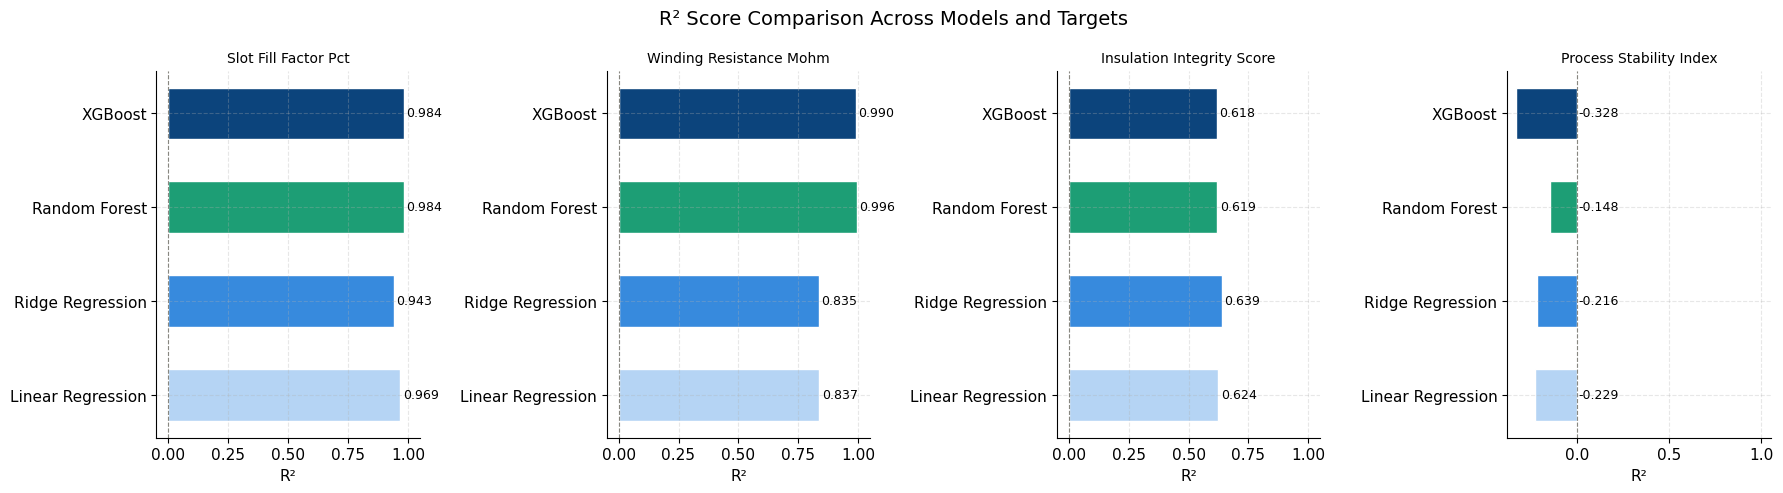

Saved: 12_regression_r2_comparison.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('R² Score Comparison Across Models and Targets', fontsize=14, fontweight='500')

colors = ['#B5D4F4', '#378ADD', '#1D9E75', '#0C447C']
model_names = list(models.keys())

for ax, target in zip(axes, TARGETS_REG):
    r2_vals = [results[target][m]['R2'] for m in model_names]
    bars = ax.barh(model_names, r2_vals, color=colors, edgecolor='white', height=0.55)
    ax.set_xlim(min(0, min(r2_vals)) - 0.05, 1.05)
    ax.axvline(0, color='#888780', lw=0.8, linestyle='--')
    ax.set_title(target.replace('_', ' ').title(), fontsize=10)
    ax.set_xlabel('R²')
    for bar, val in zip(bars, r2_vals):
        ax.text(max(val, 0) + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/plots/12_regression_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 12_regression_r2_comparison.png")


## 7. Actual vs Predicted Plots — Best Model per Target

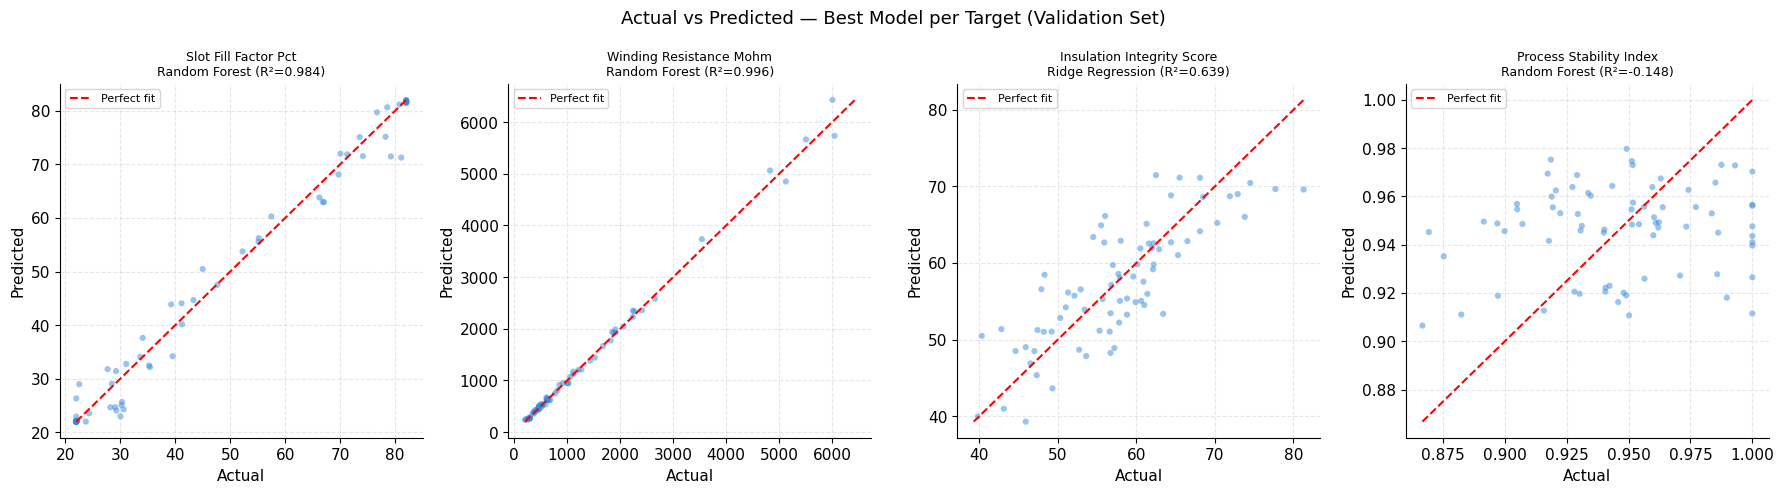

Saved: 13_actual_vs_predicted.png


In [8]:
def best_model_for(target):
    return max(results[target], key=lambda m: results[target][m]['R2'])

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Actual vs Predicted — Best Model per Target (Validation Set)', fontsize=13)

for ax, target in zip(axes, TARGETS_REG):
    best = best_model_for(target)
    preds = predictions[target][best]
    actual = y_val[target].values
    ax.scatter(actual, preds, alpha=0.5, s=20, color='#378ADD', edgecolors='none')
    mn = min(actual.min(), preds.min())
    mx = max(actual.max(), preds.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect fit')
    r2 = results[target][best]['R2']
    ax.set_title(f"{target.replace('_',' ').title()}\n{best} (R²={r2:.3f})", fontsize=9)
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../results/plots/13_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 13_actual_vs_predicted.png")


## 8. Residual Analysis

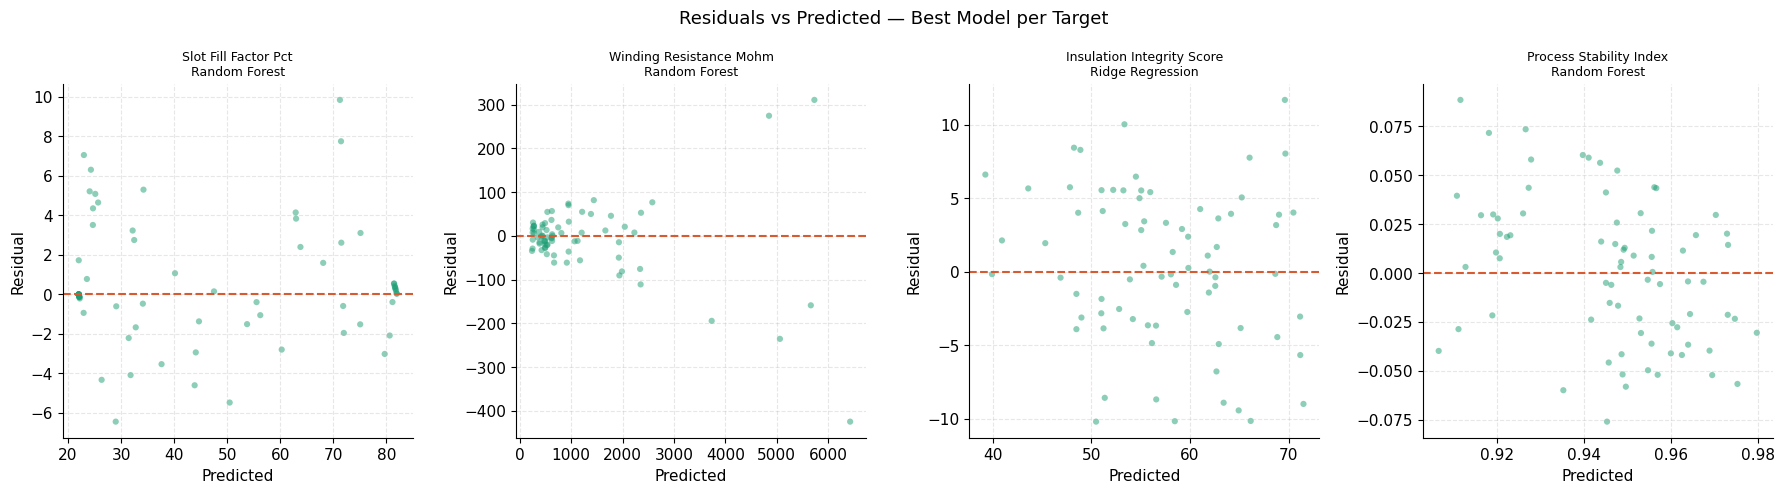

Saved: 14_residuals.png


In [9]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Residuals vs Predicted — Best Model per Target', fontsize=13)

for ax, target in zip(axes, TARGETS_REG):
    best  = best_model_for(target)
    preds = predictions[target][best]
    resid = y_val[target].values - preds
    ax.scatter(preds, resid, alpha=0.5, s=20, color='#1D9E75', edgecolors='none')
    ax.axhline(0, color='#D85A30', lw=1.5, linestyle='--')
    ax.set_title(f"{target.replace('_',' ').title()}\n{best}", fontsize=9)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual')

plt.tight_layout()
plt.savefig('../results/plots/14_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 14_residuals.png")


## 9. Cross-Validation (5-Fold) on Best Models

In [10]:
X_full_train = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

print("5-Fold Cross-Validation Results (R²):")
print(f"{'Target':<35} {'Model':<22} {'Mean R²':>8} {'Std':>8}")
print("-" * 78)

cv_results = {}
for target in TARGETS_REG:
    best_name = best_model_for(target)
    best_mdl  = models[best_name]
    y_full    = pd.concat([y_train[target], y_val[target]]).reset_index(drop=True)
    scores    = cross_val_score(best_mdl, X_full_train, y_full, cv=cv, scoring='r2', n_jobs=-1)
    cv_results[target] = {'model': best_name, 'mean': scores.mean(), 'std': scores.std(), 'scores': scores}
    print(f"{target:<35} {best_name:<22} {scores.mean():>8.4f} {scores.std():>8.4f}")


5-Fold Cross-Validation Results (R²):
Target                              Model                   Mean R²      Std
------------------------------------------------------------------------------
slot_fill_factor_pct                Random Forest            0.9851   0.0055
winding_resistance_mOhm             Random Forest            0.9955   0.0014
insulation_integrity_score          Ridge Regression         0.7471   0.0405
process_stability_index             Random Forest            0.0683   0.0535


## 10. Learning Curves — Best Model for Slot Fill Factor

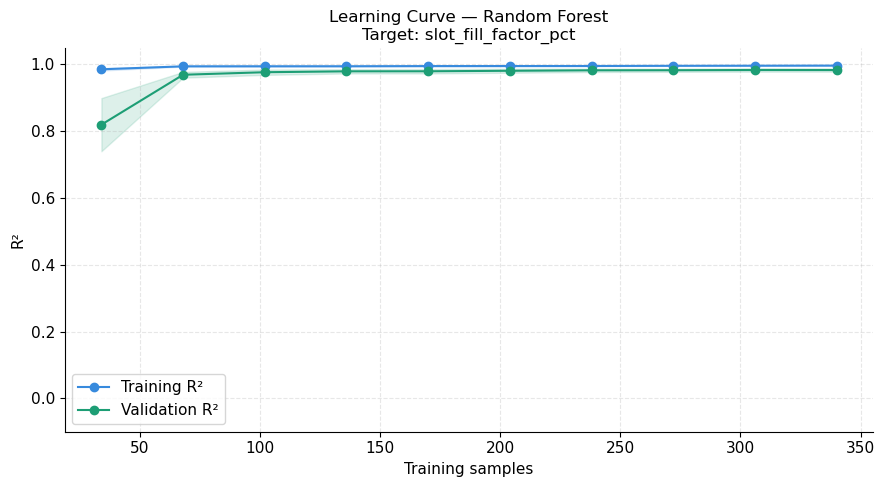

Saved: 15_learning_curve.png


In [11]:
target   = 'slot_fill_factor_pct'
best_name = best_model_for(target)
best_mdl  = models[best_name]
y_full    = pd.concat([y_train[target], y_val[target]]).reset_index(drop=True)

train_sizes, train_scores, val_scores = learning_curve(
    best_mdl, X_full_train, y_full,
    cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#378ADD', label='Training R²')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='#378ADD')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#1D9E75', label='Validation R²')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='#1D9E75')
ax.set_title(f'Learning Curve — {best_name}\nTarget: {target}', fontsize=12)
ax.set_xlabel('Training samples')
ax.set_ylabel('R²')
ax.legend()
ax.set_ylim(-0.1, 1.05)
plt.tight_layout()
plt.savefig('../results/plots/15_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: 15_learning_curve.png")


## 11. Final Evaluation on Hold-Out Test Set

In [12]:
print("HOLD-OUT TEST SET RESULTS")
print("=" * 65)
print(f"{'Target':<35} {'Model':<22} {'R²':>7}")
print("-" * 65)

best_models = {}
for target in TARGETS_REG:
    best_name = best_model_for(target)
    best_mdl  = models[best_name]
    # Retrain on train+val combined
    X_tv = pd.concat([X_train, X_val]).reset_index(drop=True)
    y_tv = pd.concat([y_train[target], y_val[target]]).reset_index(drop=True)
    best_mdl.fit(X_tv, y_tv)
    test_preds = best_mdl.predict(X_test)
    r2   = r2_score(y_test[target], test_preds)
    mae  = mean_absolute_error(y_test[target], test_preds)
    rmse = np.sqrt(mean_squared_error(y_test[target], test_preds))
    best_models[target] = best_mdl
    print(f"{target:<35} {best_name:<22} {r2:>7.4f}  MAE={mae:.3f}  RMSE={rmse:.3f}")

# Save best regression models
joblib.dump(best_models, '../src/best_regression_models.pkl')
print("\nBest models saved to ../src/best_regression_models.pkl")


HOLD-OUT TEST SET RESULTS
Target                              Model                       R²
-----------------------------------------------------------------
slot_fill_factor_pct                Random Forest           0.9875  MAE=1.209  RMSE=2.213
winding_resistance_mOhm             Random Forest           0.9964  MAE=70.933  RMSE=117.593
insulation_integrity_score          Ridge Regression        0.8119  MAE=3.423  RMSE=4.221
process_stability_index             Random Forest          -0.1048  MAE=0.040  RMSE=0.051

Best models saved to ../src/best_regression_models.pkl


## 12. Regression Summary

In [13]:
print("=" * 55)
print("REGRESSION SUMMARY")
print("=" * 55)
for target in TARGETS_REG:
    best = best_model_for(target)
    r2   = results[target][best]['R2']
    cv_r2 = cv_results[target]['mean']
    cv_std = cv_results[target]['std']
    print(f"\n  {target}")
    print(f"    Best model : {best}")
    print(f"    Val R²     : {r2:.4f}")
    print(f"    CV R²      : {cv_r2:.4f} ± {cv_std:.4f}")

print("\nNEXT STEP → 04_Classification.ipynb")


REGRESSION SUMMARY

  slot_fill_factor_pct
    Best model : Random Forest
    Val R²     : 0.9842
    CV R²      : 0.9851 ± 0.0055

  winding_resistance_mOhm
    Best model : Random Forest
    Val R²     : 0.9957
    CV R²      : 0.9955 ± 0.0014

  insulation_integrity_score
    Best model : Ridge Regression
    Val R²     : 0.6389
    CV R²      : 0.7471 ± 0.0405

  process_stability_index
    Best model : Random Forest
    Val R²     : -0.1476
    CV R²      : 0.0683 ± 0.0535

NEXT STEP → 04_Classification.ipynb
